# CommerceLens — Layer 3: Model

**Anchor question:** *…which operational factors drive customer satisfaction and repeat purchases?*

Layer 2 described these drivers after the fact. This layer asks whether they can be **predicted early enough to act on**. The model is deliberately small: the aim is a trustworthy risk score and an explanation, not leaderboard performance.

**Prediction time = the moment the order is placed.** Features come from `sql/18_order_features.sql`:

| Used (known at purchase) | Excluded (leakage) |
|---|---|
| Order value, freight, freight ratio, item/seller counts | Actual delivery date, carrier hand-off date |
| Promised delivery window (estimated − purchase date) | `delay_days` (only known after delivery) |
| Main category, weight, volume, photos, description length | Order approval timestamp |
| Payment type, installments | Anything from the review itself |
| Customer & seller state, same-state flag, seller→customer distance | Future orders of the customer |
| Seller's and customer's **prior** order counts (strictly earlier orders) | |

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import shap
from IPython.display import display
from sklearn.metrics import precision_recall_curve, roc_curve

from src import db, features as F, model as M

pd.set_option("display.float_format", "{:,.4f}".format)
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#8a8983"
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GREY, "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.titleweight": "bold", "axes.titlesize": 12,
})

con = db.connect()

## 1. Choosing the target

Two candidates:
- **Repeat purchase**: does a customer place another delivered order within 180 days of their first? One row per customer, features from the first order, and only customers with a full 180-day window are included.
- **Low review**: will this order get a 1–2 star review? One row per delivered order with a review.

Both get the same LightGBM setup and the same stratified 80/20 split. The one with **usable signal** is chosen: a meaningful PR-AUC lift over the positive rate, and enough positives to act on.

In [2]:
candidates = {}
for name, loader in [("Repeat purchase (180d)", F.repeat_dataset), ("Low review (1-2 stars)", F.low_review_dataset)]:
    X, y, ts = loader(con)
    X_tr, X_te, y_tr, y_te = M.split(X, y)
    m = M.train_lgbm(X_tr, y_tr)
    scores = m.predict_proba(X_te)[:, 1]
    candidates[name] = dict(rows=len(y), positives=int(y.sum()), **M.evaluate(y_te, scores),
                            **{k: v for k, v in M.capture_at_top(y_te, scores).items() if k != "top_frac"})
cand = pd.DataFrame(candidates).T
display(cand)

# Decision rule: pick the target with the higher PR-AUC lift; report ROC-AUC alongside.
chosen = cand["pr_auc_lift"].astype(float).idxmax()
other = [c for c in cand.index if c != chosen][0]
print(f"Chosen target: {chosen}")
print(f"  positive rate {cand.loc[chosen, 'positive_rate']:.1%}, ROC-AUC {cand.loc[chosen, 'roc_auc']:.3f}, "
      f"PR-AUC {cand.loc[chosen, 'pr_auc']:.3f} ({cand.loc[chosen, 'pr_auc_lift']:.2f}x the positive rate)")
print(f"Rejected: {other}")
print(f"  positive rate {cand.loc[other, 'positive_rate']:.1%}, ROC-AUC {cand.loc[other, 'roc_auc']:.3f}, "
      f"PR-AUC {cand.loc[other, 'pr_auc']:.3f} ({cand.loc[other, 'pr_auc_lift']:.2f}x); "
      f"precision in the top 10% of scores only {cand.loc[other, 'precision_at_top']:.1%}")

,rows,positives,positive_rate,roc_auc,pr_auc,pr_auc_lift,precision_at_top,recall_at_top
Repeat purchase (180d),"55,907.0000","1,736.0000",0.0310,0.6115,0.0478,1.5394,0.0518,0.1671
Low review (1-2 stars),"95,832.0000","12,273.0000",0.1281,0.6731,0.2693,2.1026,0.3276,0.2558


Chosen target: Low review (1-2 stars)
  positive rate 12.8%, ROC-AUC 0.673, PR-AUC 0.269 (2.10x the positive rate)
Rejected: Repeat purchase (180d)
  positive rate 3.1%, ROC-AUC 0.612, PR-AUC 0.048 (1.54x); precision in the top 10% of scores only 5.2%


**Why this choice.** Repeat purchase is rare (about 3% positive, because most customers buy once, as Layer 1 showed). Layer 2 also found that first-order experience barely moves it, so there is little operational signal to learn from, and even the highest-risk decile is mostly customers who never return. Low reviews are about 4× more common, clearly more predictable, and directly actionable: Layer 2 tied them to delivery performance. **The rest of this notebook models low reviews.**

## 2. Final model: LightGBM vs baselines

In [3]:
X, y, ts = F.low_review_dataset(con)
X_tr, X_te, y_tr, y_te = M.split(X, y)
print(f"{len(X):,} orders, {X.shape[1]} features, positive rate {y.mean():.2%} "
      f"(train {y_tr.mean():.2%} / test {y_te.mean():.2%} - stratified)")

lgbm = M.train_lgbm(X_tr, y_tr)
logit = M.train_logistic(X_tr, y_tr)
p_lgbm = lgbm.predict_proba(X_te)[:, 1]
p_logit = logit.predict_proba(X_te)[:, 1]

results = pd.DataFrame({
    "No-skill baseline": {"roc_auc": 0.5, "pr_auc": y_te.mean()},
    "Logistic regression": {k: v for k, v in M.evaluate(y_te, p_logit).items() if k in ("roc_auc", "pr_auc")},
    "LightGBM": {k: v for k, v in M.evaluate(y_te, p_lgbm).items() if k in ("roc_auc", "pr_auc")},
}).T
results["pr_auc_lift"] = results["pr_auc"] / y_te.mean()
print(f"LightGBM stopped at {lgbm.best_iteration_} trees (early stopping on an inner validation split).")
display(results)

95,832 orders, 24 features, positive rate 12.81% (train 12.81% / test 12.81% - stratified)


LightGBM stopped at 455 trees (early stopping on an inner validation split).


,roc_auc,pr_auc,pr_auc_lift
No-skill baseline,0.5000,0.1281,1.0000
Logistic regression,0.6294,0.2324,1.8146
LightGBM,0.6731,0.2693,2.1026


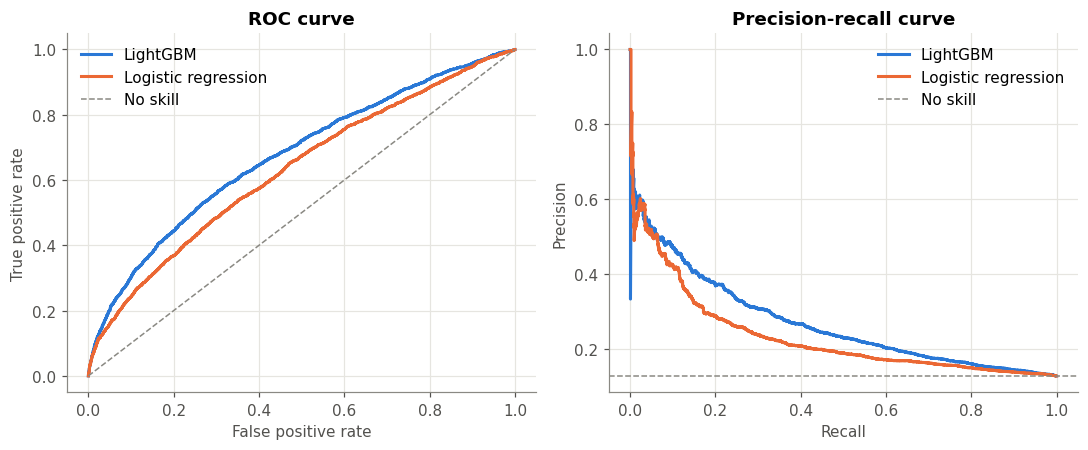

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for p, label, color in [(p_lgbm, "LightGBM", BLUE), (p_logit, "Logistic regression", ORANGE)]:
    fpr, tpr, _ = roc_curve(y_te, p)
    prec, rec, _ = precision_recall_curve(y_te, p)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=label)
    axes[1].plot(rec, prec, color=color, lw=2, label=label)
axes[0].plot([0, 1], [0, 1], color=GREY, ls="--", lw=1, label="No skill")
axes[1].axhline(y_te.mean(), color=GREY, ls="--", lw=1, label="No skill")
axes[0].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC curve")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-recall curve")
for ax in axes:
    ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 3. What the score is worth operationally

A risk score is useful if a small, reviewable slice of orders captures a large share of future low reviews.

In [5]:
cap = pd.DataFrame([M.capture_at_top(y_te, p_lgbm, f) for f in (0.05, 0.10, 0.20, 0.30)])
cap["lift_vs_random"] = cap["precision_at_top"] / y_te.mean()
display(cap)
c10 = cap.set_index("top_frac").loc[0.10]
print(f"Flagging the riskiest 10% of orders at purchase captures {c10.recall_at_top:.1%} of all low reviews, "
      f"with {c10.precision_at_top:.1%} precision ({c10.lift_vs_random:.1f}x the {y_te.mean():.1%} base rate).")

,top_frac,precision_at_top,recall_at_top,lift_vs_random
0,0.0500,0.4025,0.1572,3.1425
1,0.1000,0.3276,0.2558,2.5576
2,0.2000,0.2626,0.4102,2.0506
3,0.3000,0.2250,0.5271,1.7567


Flagging the riskiest 10% of orders at purchase captures 25.6% of all low reviews, with 32.8% precision (2.6x the 12.8% base rate).


## 4. Robustness: time-based holdout

A random split lets the model see orders from every month, including the periods when low reviews spiked (Nov 2017, Feb–Mar 2018). That makes `purchase_month` look more predictive than it will be in future. The honest test is to **train on the past and score the future**.

In [6]:
monthly_rate = pd.Series(y.values, index=ts.dt.to_period("M")).groupby(level=0).agg(["mean", "size"])
display(monthly_rate[monthly_rate["size"] >= 500].rename(columns={"mean": "low_review_rate", "size": "orders"}).T)

cut = pd.Timestamp("2018-05-01")
past, future = ts < cut, ts >= cut
lgbm_t = M.train_lgbm(X[past], y[past])
temporal = M.evaluate(y[future], lgbm_t.predict_proba(X[future])[:, 1])
random_split = M.evaluate(y_te, p_lgbm)
robust = pd.DataFrame({"Stratified random split": random_split, f"Train < {cut:%Y-%m-%d}, test after": temporal}).T
display(robust)
print(f"Out-of-time: ROC-AUC {temporal['roc_auc']:.3f}, PR-AUC {temporal['pr_auc']:.3f} = {temporal['pr_auc_lift']:.2f}x "
      f"the {temporal['positive_rate']:.1%} base rate (test = {future.sum():,} orders).")

order_purchase_timestamp,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08
low_review_rate,0.1201,0.1108,0.1124,0.1293,0.1006,0.1074,0.0994,0.0939,0.1027,0.1107,0.1657,0.1443,0.1370,0.1938,0.2117,0.1179,0.1076,0.0999,0.0967,0.0954
orders,741.0000,"1,643.0000","2,527.0000","2,290.0000","3,518.0000","3,111.0000","3,842.0000","4,165.0000","4,118.0000","4,446.0000","7,238.0000","5,461.0000","7,013.0000","6,507.0000","6,948.0000","6,752.0000","6,722.0000","6,075.0000","6,121.0000","6,330.0000"


,positive_rate,roc_auc,pr_auc,pr_auc_lift
Stratified random split,0.1281,0.6731,0.2693,2.1026
"Train < 2018-05-01, test after",0.1000,0.6112,0.1812,1.8109


Out-of-time: ROC-AUC 0.611, PR-AUC 0.181 = 1.81x the 10.0% base rate (test = 25,248 orders).


## 5. SHAP: what drives predicted low-review risk?

SHAP values explain each prediction as a sum of per-feature contributions (in log-odds). Mean |SHAP| ranks features by overall influence, computed on a 5,000-order test sample.

,feature,mean_abs_shap
0,purchase_month,0.2102
1,customer_state,0.1625
2,n_items,0.1471
3,main_category,0.1458
4,seller_state,0.0770
5,promised_days,0.0505
6,freight_value,0.0484
7,distance_km,0.0483
8,avg_description_length,0.0471
9,seller_prior_orders,0.0443


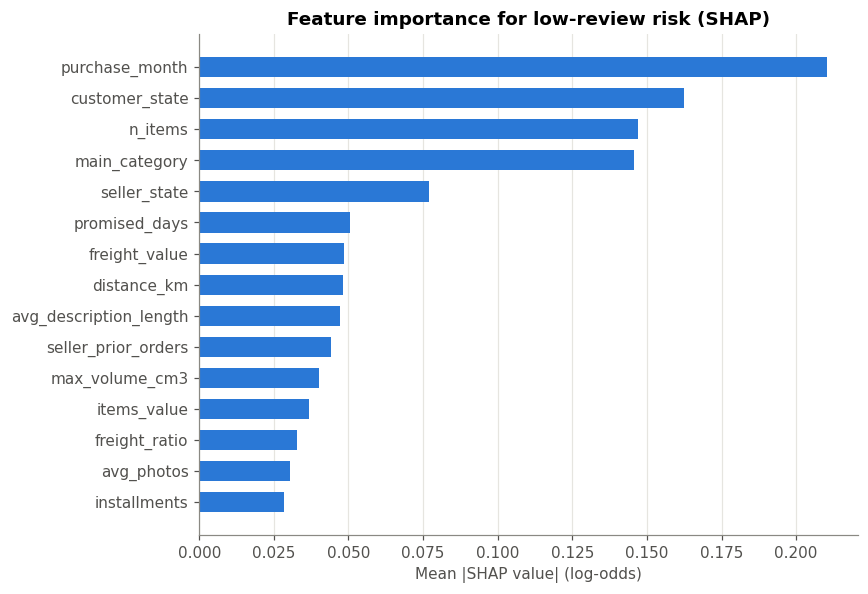

In [7]:
shap_values, X_sample, importance = M.shap_importance(lgbm, X_te)
display(importance)

top = importance.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top["feature"], top["mean_abs_shap"], color=BLUE, height=0.65)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Mean |SHAP value| (log-odds)")
ax.set_title("Feature importance for low-review risk (SHAP)")
plt.tight_layout(); plt.show()

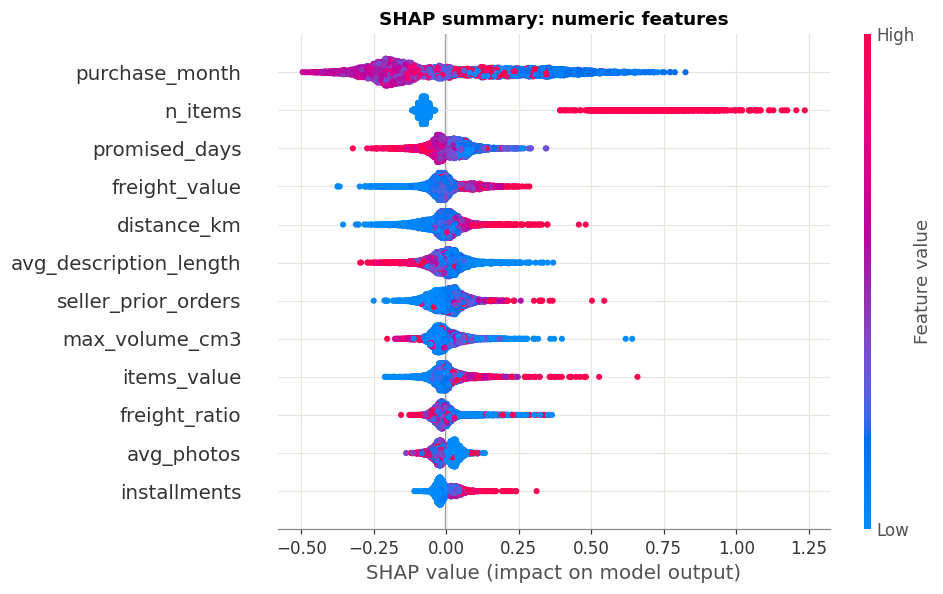

In [8]:
# Beeswarm for numeric features: direction of each effect (red = high feature value).
num_cols = [c for c in importance["feature"] if c in F.NUMERIC_FEATURES][:12]
idx = [X_sample.columns.get_loc(c) for c in num_cols]
shap.summary_plot(shap_values[:, idx], X_sample[num_cols], show=False, plot_size=(9, 5.5))
plt.title("SHAP summary: numeric features", fontweight="bold")
plt.tight_layout(); plt.show()

In [9]:
# Categorical effects: average SHAP contribution per customer state (positive = raises risk).
state_effect = (
    pd.DataFrame({"customer_state": X_sample["customer_state"].astype(str).values,
                  "shap": shap_values[:, X_sample.columns.get_loc("customer_state")]})
    .groupby("customer_state")["shap"].agg(["mean", "size"])
    .query("size >= 50").sort_values("mean", ascending=False)
)
display(state_effect.head(8))

cat_effect = (
    pd.DataFrame({"main_category": X_sample["main_category"].astype(str).values,
                  "shap": shap_values[:, X_sample.columns.get_loc("main_category")]})
    .groupby("main_category")["shap"].agg(["mean", "size"])
    .query("size >= 50").sort_values("mean", ascending=False)
)
display(cat_effect.head(8))

,mean,size
customer_state,,
RJ,0.3998,623
BA,0.3775,179
PA,0.2994,53
PE,0.1764,81
CE,0.1571,56
DF,0.0335,110
ES,-0.0084,99
GO,-0.0128,110


,mean,size
main_category,,
unknown,0.2638,73
computers_accessories,0.2262,331
telephony,0.2062,194
office_furniture,0.1760,73
baby,0.1740,149
bed_bath_table,0.1502,478
furniture_decor,0.0833,335
auto,0.0605,216


In [10]:
# Direction of key operational effects: mean SHAP in low vs high halves of each feature.
def direction(feature):
    v = X_sample[feature]
    s = shap_values[:, X_sample.columns.get_loc(feature)]
    hi = v > v.median()
    return pd.Series({"median": v.median(), "mean_shap_below_median": s[~hi].mean(), "mean_shap_above_median": s[hi].mean()})

display(pd.DataFrame({f: direction(f) for f in ["n_items", "distance_km", "freight_value", "promised_days",
                                                 "seller_prior_orders", "same_state"]}).T)

,median,mean_shap_below_median,mean_shap_above_median
n_items,1.0000,-0.0783,0.7163
distance_km,434.0141,-0.0442,0.0275
freight_value,17.2000,-0.0391,0.0381
promised_days,24.0000,0.0499,-0.0408
seller_prior_orders,62.0000,-0.0371,0.0399
same_state,0.0000,0.0145,-0.0244


## 6. Layer 3 summary

In [11]:
rank = {f: i + 1 for i, f in enumerate(importance["feature"])}
top5 = ", ".join(importance["feature"].head(5))
top_states = ", ".join(state_effect.head(3).index)
lr = results.loc["Logistic regression"]; lg = results.loc["LightGBM"]
print(f"- Target: {chosen}. Repeat purchase rejected (positive rate {cand.loc[other, 'positive_rate']:.1%}, PR-AUC lift {cand.loc[other, 'pr_auc_lift']:.2f}x).")
print(f"- LightGBM (stratified test): ROC-AUC {lg.roc_auc:.3f}, PR-AUC {lg.pr_auc:.3f} vs no-skill {y_te.mean():.3f} ({lg.pr_auc_lift:.2f}x); "
      f"logistic baseline ROC-AUC {lr.roc_auc:.3f}, PR-AUC {lr.pr_auc:.3f}.")
print(f"- Out-of-time test (after {cut:%Y-%m}): ROC-AUC {temporal['roc_auc']:.3f}, PR-AUC {temporal['pr_auc']:.3f} ({temporal['pr_auc_lift']:.2f}x base rate).")
print(f"- Riskiest 10% of orders capture {c10.recall_at_top:.1%} of low reviews at {c10.precision_at_top:.1%} precision.")
print(f"- Top SHAP drivers: {top5}. Highest-risk customer states: {top_states}.")
dirs = pd.DataFrame({f: direction(f) for f in ["n_items", "promised_days", "distance_km"]}).T
print(f"- Multi-item orders raise risk (mean SHAP {dirs.loc['n_items', 'mean_shap_above_median']:+.2f} vs {dirs.loc['n_items', 'mean_shap_below_median']:+.2f}); "
      f"longer promised windows lower it ({dirs.loc['promised_days', 'mean_shap_above_median']:+.3f} above median vs {dirs.loc['promised_days', 'mean_shap_below_median']:+.3f}); "
      f"longer distance raises it ({dirs.loc['distance_km', 'mean_shap_above_median']:+.3f} vs {dirs.loc['distance_km', 'mean_shap_below_median']:+.3f}).")

- Target: Low review (1-2 stars). Repeat purchase rejected (positive rate 3.1%, PR-AUC lift 1.54x).
- LightGBM (stratified test): ROC-AUC 0.673, PR-AUC 0.269 vs no-skill 0.128 (2.10x); logistic baseline ROC-AUC 0.629, PR-AUC 0.232.
- Out-of-time test (after 2018-05): ROC-AUC 0.611, PR-AUC 0.181 (1.81x base rate).
- Riskiest 10% of orders capture 25.6% of low reviews at 32.8% precision.
- Top SHAP drivers: purchase_month, customer_state, n_items, main_category, seller_state. Highest-risk customer states: RJ, BA, PA.
- Multi-item orders raise risk (mean SHAP +0.72 vs -0.08); longer promised windows lower it (-0.041 above median vs +0.050); longer distance raises it (+0.028 vs -0.044).


### How to read this, and limitations
- **This is a triage score, not an oracle.** At purchase time the model cannot see the thing that matters most (whether the delivery will actually be late, Layer 2's dominant driver), so moderate AUC is expected. A score re-run at carrier hand-off, with in-transit signals, would be the natural next step.
- **Time effects.** `purchase_month` partly encodes period-specific logistics shocks. The out-of-time test is the fair performance estimate, and the random split is the optimistic one.
- **Where SHAP agrees with Layer 2:** the highest-risk customer states are the same late-delivery states Layer 2 found, longer seller-to-customer distance raises risk, and a longer promised window lowers it. Reviews react to delivery against the promise, which supports fixing lanes and setting realistic promises. Multi-item orders are the strongest order-level risk flag.
- **SHAP describes the model, not causality.**
- Scope: delivered orders with a review, Brazil 2016–2018.